# Tracking Data Analysis
Reload and analyze time_tracking data from saved CSVs

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from slab_qick_calib.calib.time_tracking import load_tracking
from slab_qick_calib.analysis import collections, allan, qubit_params
from slab_qick_calib.helpers import config

%load_ext autoreload
%autoreload 2

<module 'slab_qick_calib.experiments' from 'C:\\_Lib\\python\\slab_qick_calib\\experiments\\__init__.py'>
C:\_Lib\python\slab_qick_calib\experiments
imported slab_qick_calib.experiments.general.qick_experiment
imported slab_qick_calib.experiments.general.qick_experiment_2q
imported slab_qick_calib.experiments.general.qick_program
C:\_Lib\python\slab_qick_calib\experiments\general
C:\_Lib\python\slab_qick_calib\experiments\single_qubit
imported slab_qick_calib.experiments.single_qubit.active_reset
imported slab_qick_calib.experiments.single_qubit.pulse_probe_spectroscopy
imported slab_qick_calib.experiments.single_qubit.rabi
imported slab_qick_calib.experiments.single_qubit.resonator_spectroscopy
imported slab_qick_calib.experiments.single_qubit.single_shot
imported slab_qick_calib.experiments.single_qubit.single_shot_opt
imported slab_qick_calib.experiments.single_qubit.stark_spectroscopy
imported slab_qick_calib.experiments.single_qubit.t1
imported slab_qick_calib.experiments.single_q

## Configuration

In [2]:
cfg_file = '2026_02_09_smpd_v2.yml'
expt_path = r'C:\_Data\SMPD'
cfg_path = os.path.join(os.getcwd(), '..', 'configs', cfg_file)

csv_dir = os.path.join(expt_path, 'Tracking', 'csv')
qubit_list = [0]

## Load tracking data from CSVs

In [4]:
tt, csv_pth, tt_stats, tracking_id = load_tracking(csv_dir)

Loaded tracking_id='2026_02_14_12_22_6.0hrs', qubits=[1]


## Process data and add derived quantities

In [ ]:
tt, tt_ave = collections.process_data(tt)
tt = collections.add_losses(tt)

## Allan variance analysis

In [ ]:
allan.perform_analysis(tt, param='Gamma1', save_path=csv_pth, tracking_id=tracking_id)

## Time series and histograms

In [ ]:
collections.plot_all(tt, param_keys=['t1', 'tphi', 'f_ge', 't2_r2'], save_path=csv_pth, tracking_id=tracking_id)

In [ ]:
collections.plot_all(tt, param_keys=['Gamma1', 'Gamma2', 'Gammaphi', 't2_r2'], plot_time=True, save_path=csv_pth, tracking_id=tracking_id)

## Violin plots

(<Figure size 700x600 with 4 Axes>,
 array([<AxesSubplot: xlabel='Qubit', ylabel='$\\Gamma_1$ (ms$^{-1}$)'>,
        <AxesSubplot: xlabel='Qubit', ylabel='$\\Gamma_{\\phi}$ (ms$^{-1}$)'>,
        <AxesSubplot: xlabel='Qubit', ylabel='$Q_1$'>,
        <AxesSubplot: xlabel='Qubit', ylabel='$f-\\overline{f}$ (kHz), Qubit '>],
       dtype=object))

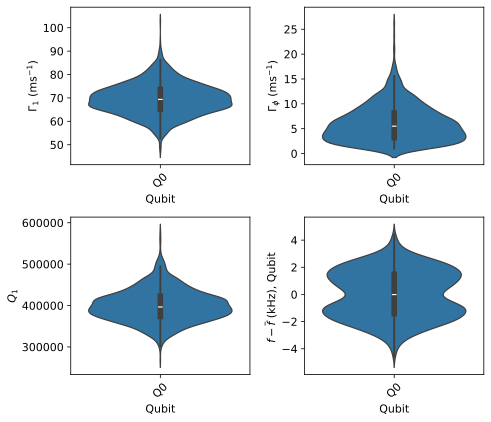

In [ ]:
collections.plot_violin(tt, param_keys=['Gamma1', 'Gammaphi', 'q', 'f_ge'], csv_path=csv_pth)

In [ ]:
tt[0]

{'t1': array([12.52844, 13.85835, 12.92761, ..., 13.59089, 11.86185, 12.88699]),
 't1_off': array([ -6.32814,  -8.00346,  -5.60407, ..., -16.07557,  -5.9728 ,
         -9.67252]),
 't1_amp': array([21.89781, 23.09034, 20.03797, ..., 28.56324, 21.64204, 23.0785 ]),
 't2_off': array([5.93018, 6.15045, 6.41982, ..., 1.31917, 3.27858, 8.44731]),
 't2_amp': array([ 8.33926,  7.23551,  8.28347, ..., 10.74709,  9.01058,  7.23772]),
 't2': array([25.37035, 28.14399, 26.64893, ..., 26.57043, 29.81469, 24.31802]),
 'f_ge': array([4378.57124, 4378.57298, 4378.57312, ..., 4378.57037, 4378.57285,
        4378.56874]),
 't2_err': array([2.98807, 3.79033, 2.7586 , ..., 2.5757 , 3.52473, 2.57121]),
 'fge_err': array([0.00083, 0.00086, 0.00068, ..., 0.00064, 0.0007 , 0.0008 ]),
 't1_err': array([1.01877, 1.33939, 1.64547, ..., 1.06827, 0.64724, 1.14866]),
 't1_r2': array([0.96946, 0.9744 , 0.94736, ..., 0.97863, 0.98919, 0.97768]),
 't2_r2': array([0.87505, 0.85667, 0.9045 , ..., 0.92274, 0.88476, 0.89

## Power Spectral Density Analysis

In [ ]:
from slab_qick_calib.analysis.time_series import analyze_qubit_psd

# Calculate sampling frequency from timestamps
timestamps = tt[0]['time']
dt = np.median(np.diff(timestamps))  # median time between measurements (in seconds)
fs = 1 / dt  # sampling frequency in Hz

print(f"Median time between measurements: {dt:.1f} s")
print(f"Sampling frequency: {fs:.4f} Hz")

# Analyze PSD for different parameters
params_to_analyze = ['Gamma1', 'Gammaphi', 'f_ge', 't1']

for param in params_to_analyze:
    if param in tt[0]:
        data = tt[0][param]
        print(f"\n{'='*60}")
        print(f"Analyzing {param}...")
        results = analyze_qubit_psd(
            data,
            fs=fs,
            parameter_name=param,
            qubit_id=0,
            plot=True,
            save_path=csv_pth,
            tracking_id=tracking_id,
        )
        if results:
            print(f"Peak frequency: {results['peak_freq']:.4e} Hz (Period: {1/results['peak_freq']:.1f} s)")
            print(f"Total power: {results['total_power']:.4e}")
            print(f"SNR: {results['snr_db']:.1f} dB")

## Parameter vs MXC temperature

In [ ]:
collections.plot_vs_temperature(tt, param_keys=['t1', 'tphi', 'f_ge', 'Gamma1'], save_path=csv_pth, tracking_id=tracking_id)

## Save stats to model config

In [ ]:
qubit_params.stats(cfg_path, tt_stats, qubit_list)